<a href="https://colab.research.google.com/github/naldonymous/IMDB-Sentiment-Analysis-Project/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install datasets wordcloud

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from datasets import load_dataset
from wordcloud import WordCloud

Loads the IMDB dataset, and makes data frames out of pre-labelled "training" and "testing" data.

In [28]:
datasets = load_dataset("imdb")
df_train = pd.DataFrame(datasets["train"])
df_test = pd.DataFrame(datasets["test"])
print(df_train.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


Bar graph of amount of positive and negative reviews, hoping for roughly equal amounts.

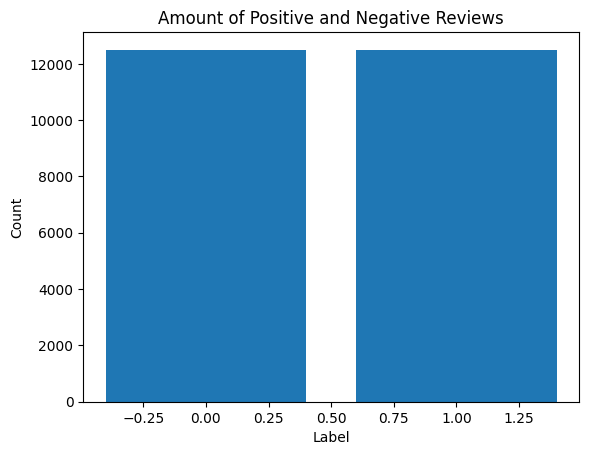

In [29]:
counts = df_train.value_counts('label')
plt.bar(counts.index, counts.values)
plt.title('Amount of Positive and Negative Reviews')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Histogram of length of reviews.

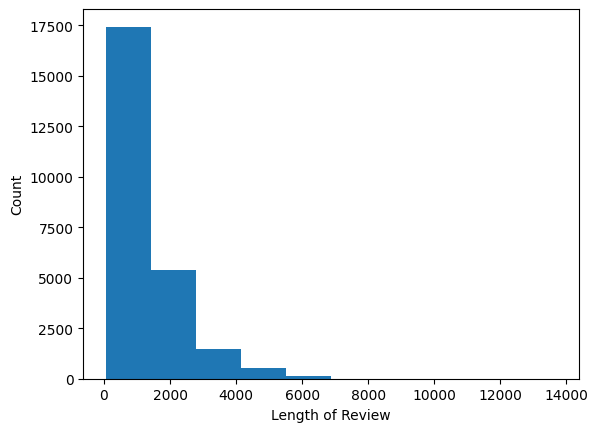

In [30]:
df_train['length'] = df_train['text'].apply(len)

plt.hist(df_train.length)
plt.xlabel('Length of Review')
plt.ylabel('Count')
plt.show()

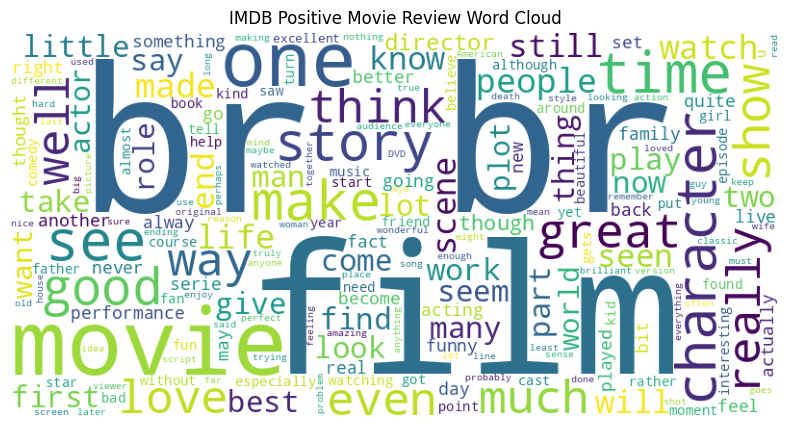

In [31]:
df_tpositive = df_train[df_train['label'] == 1]
df_tnegative = df_train[df_train['label'] == 0]

positive_text = "".join(df_tpositive['text'])
negative_text = "".join(df_tnegative['text'])

positiveWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(positiveWordCloud)
plt.axis('off')
plt.title("IMDB Positive Movie Review Word Cloud")
plt.show()

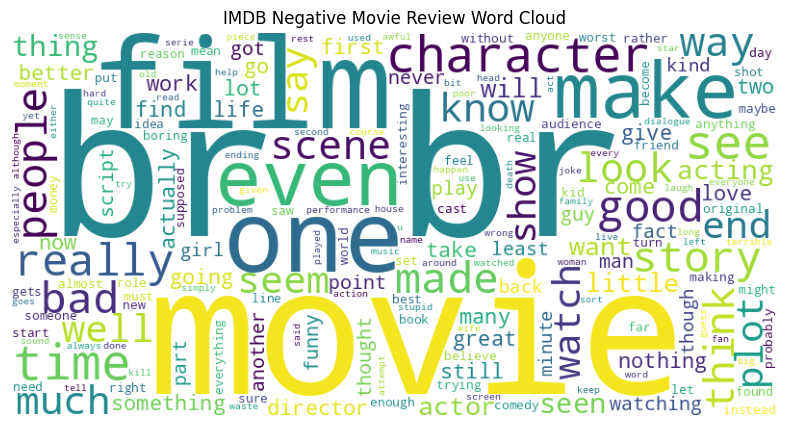

In [32]:
negativeWordCloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(negativeWordCloud)
plt.axis('off')
plt.title("IMDB Negative Movie Review Word Cloud")
plt.show()

In [33]:
X_train = df_train['text']
y_train = df_train['label']
X_test = df_test['text']
y_test = df_test['label']

In [34]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [35]:
logRegression = LogisticRegression()

logRegression.fit(X_train_tfidf, y_train)
y_pred = logRegression.predict(X_test_tfidf)

In [41]:
accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.88      0.88      0.88     12500\n           1       0.88      0.88      0.88     12500\n\n    accuracy                           0.88     25000\n   macro avg       0.88      0.88      0.88     25000\nweighted avg       0.88      0.88      0.88     25000\n'